# Section 4 — Outlier Detection with Tukey's Rule and Z-score 

## Overview
After KNN imputation (k=5), outliers are detected on five interpretable variables using **Tukey's rule** (IQR × 1.5) and **Z-score** (|Z| > 3). Tukey flags more observations on skewed pollution variables; Z-score is stricter and assumes approximate normality.

## Key Results

| Variable | Tukey count | Tukey % | Z-score count | Z-score % | Tukey bounds [L, U] |
|----------|-------------|---------|---------------|-----------|---------------------|
| CO(GT) | 359 | 3.79% | 136 | 1.44% | [−1.45, 5.19] |
| C6H6(GT) | 259 | 2.73% | 127 | 1.34% | [−9.60, 28.00] |
| T | 9 | 0.10% | 1 | 0.01% | [−6.30, 42.50] |
| RH | 0 | 0.00% | 0 | 0.00% | [−1.75, 100.25] |
| AH | 11 | 0.12% | 1 | 0.01% | [−0.07, 2.11] |

**Total flagged (Tukey):** 638 observations across 5 variables.

## Learning Objectives
- Detect outliers using Tukey's rule (IQR) and Z-score
- Compare both methods with boxplots and summary tables
- Interpret extremes in the context of air pollution data

## Your Decisions Log

| Step | Decision | Evidence (plot / table / stat) |
|------|----------|--------------------------------|
| Select variables | CO(GT), C6H6(GT), T, RH, AH | 5 pollution/environment columns |
| Visual exploration | Boxplots before formal detection | `reports/figures/outlier_boxplots.png` |
| Tukey detection | IQR rule on all 5 variables | Outlier report — 359 + 259 + 9 + 0 + 11 |
| Z-score detection | Threshold = 3.0 | Outlier report — 136 + 127 + 1 + 0 + 1 |
| Method comparison | Tukey flags ~2–3× more on skewed vars | Side-by-side counts in report table |
| Interpretation | Extremes may be real peaks or sensor glitches | CO(GT) and C6H6(GT) most affected |

## Suggested Variables
CO(GT), C6H6(GT), NOx(GT), NO2(GT), T, RH, AH

## Tasks
- a) Generate boxplots for selected variables
- b) Detect outliers using Tukey's rule
- c) Detect outliers using Z-score
- d) Create outlier count/percentage table per method
- e) Compare results of both methods

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from src.config import RAW_DATA_PATH, MISSING_SENTINEL, KNN_K_VALUES, ZSCORE_THRESHOLD, FIGURES_DIR
from src.plot_style import apply_plot_style, style_table, PALETTE
from src.load_data import load_raw_air_quality, build_datetime
from src.missing_values import replace_sentinel_with_nan
from src.knn_imputation import select_numerical_columns, knn_impute
from src.outliers import (
    tukey_bounds,
    detect_tukey_outliers,
    detect_zscore_outliers,
    outlier_report,
)

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
apply_plot_style()

# Rebuild the imputed dataset so the outlier notebook can run independently.
df = load_raw_air_quality(RAW_DATA_PATH)
df = build_datetime(df)
df = replace_sentinel_with_nan(df, sentinel=MISSING_SENTINEL)
num_cols = select_numerical_columns(df)
df = knn_impute(df, num_cols, n_neighbors=KNN_K_VALUES[-1])

# Use the variables that are most interpretable for pollution analysis.
OUTLIER_COLUMNS = ['CO(GT)', 'C6H6(GT)', 'T', 'RH', 'AH']
display(style_table(df[OUTLIER_COLUMNS].head()))

CO(GT),C6H6(GT),T,RH,AH
2.600000,11.900000,13.600000,48.900000,0.757800
2.000000,9.400000,13.300000,47.700000,0.725500
2.200000,9.000000,11.900000,54.000000,0.750200
2.200000,9.200000,11.000000,60.000000,0.786700
1.600000,6.500000,11.200000,59.600000,0.788800


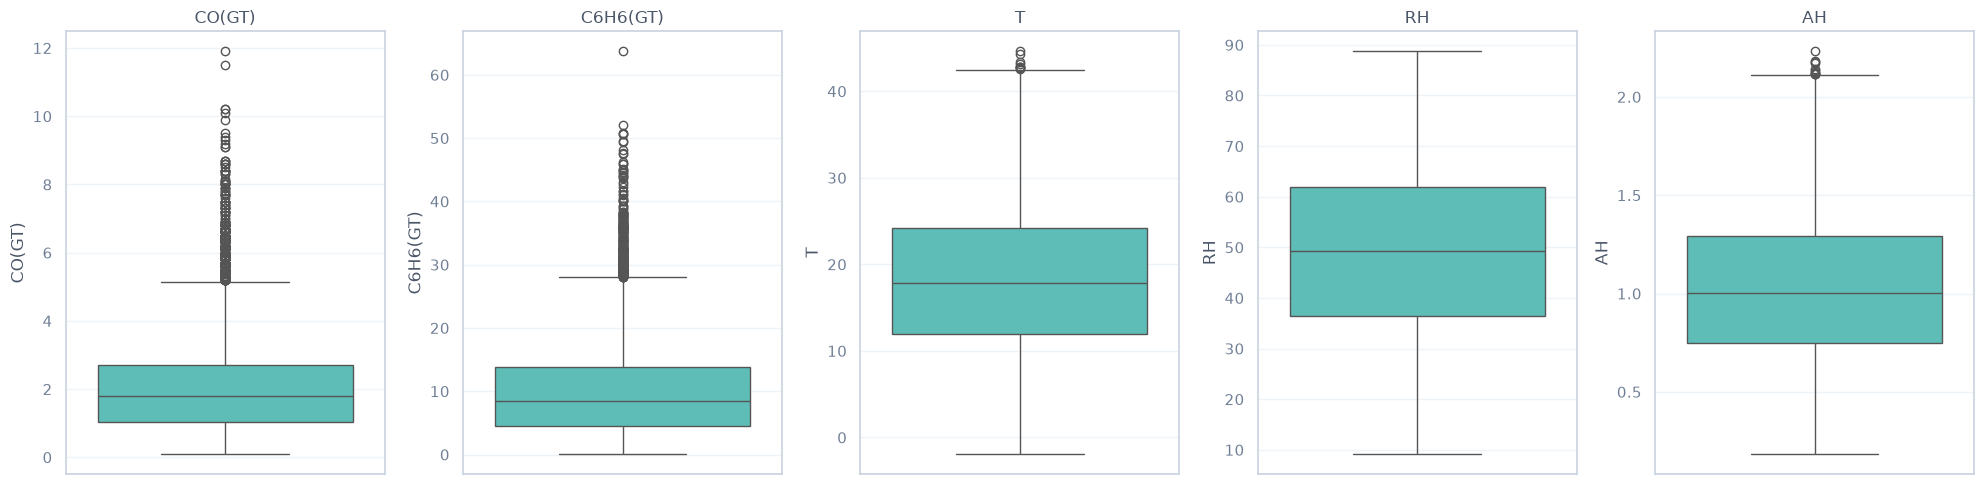

In [2]:
# Boxplots give a fast view of spread and extreme values before formal detection.
fig, axes = plt.subplots(1, len(OUTLIER_COLUMNS), figsize=(4 * len(OUTLIER_COLUMNS), 5))
if len(OUTLIER_COLUMNS) == 1:
    axes = [axes]

for axis, column in zip(axes, OUTLIER_COLUMNS):
    sns.boxplot(y=df[column], ax=axis, color=PALETTE['aqua_primary'])
    axis.set_title(column)
    axis.set_xlabel('')

fig.tight_layout()
fig.savefig(FIGURES_DIR / 'outlier_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

In [3]:
# Detect outliers with both rules and keep the counts visible for each variable.
outlier_details = []
for column in OUTLIER_COLUMNS:
    tukey_mask = detect_tukey_outliers(df[column])
    zscore_mask = detect_zscore_outliers(df[column], threshold=ZSCORE_THRESHOLD)
    lower, upper = tukey_bounds(df[column])
    outlier_details.append({
        'variable': column,
        'tukey_count': int(tukey_mask.sum()),
        'zscore_count': int(zscore_mask.sum()),
        'tukey_lower': lower,
        'tukey_upper': upper,
    })

outlier_df = pd.DataFrame(outlier_details)
display(style_table(outlier_df))

variable,tukey_count,zscore_count,tukey_lower,tukey_upper
CO(GT),359,136,-1.450000,5.190000
C6H6(GT),259,127,-9.600000,28.000000
T,9,1,-6.300000,42.500000
RH,0,0,-1.750000,100.250000
AH,11,1,-0.071825,2.112375


In [4]:
# Summarize the outliers in one table so the decision is easy to audit.
report = outlier_report(df, OUTLIER_COLUMNS)
display(style_table(report))

variable,tukey_count,tukey_pct,zscore_count,zscore_pct
CO(GT),359,3.790518,136,1.435962
C6H6(GT),259,2.734664,127,1.340935
T,9,0.095027,1,0.010559
RH,0,0.000000,0,0.000000
AH,11,0.116144,1,0.010559


## Guiding Questions

1. **Do Tukey's rule and Z-score detect the same observations as outliers?**

   No. They overlap in some cases, but they do not always flag the same observations. Z-score works better when the data are close to normal, while Tukey's rule is more robust on skewed data.

2. **Are the extreme values likely to be measurement errors, sensor behavior, or real pollution events?**

   It is likely a mix. Some extreme values may come from sensor glitches or invalid readings, while others may reflect real pollution peaks or periods of unstable sensor behavior. Each case should be checked in context.

3. **Which method is more appropriate for skewed variables? Explain your reasoning.**

   Tukey's rule is more appropriate for skewed variables because it relies on quartiles instead of the mean and standard deviation, so it is less sensitive to asymmetry and extreme tails.